In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

https://stackoverflow.com/questions/33072604/how-to-get-scipy-integrate-odeint-to-stop-when-path-is-closed

In [2]:
def model(t, y):
    return np.array([
        y[1],
        (1. - y[0]**2) * y[1] - y[0]
    ])

In [3]:
t = np.linspace(0, 25, 1000)
y0 = [4, 4]

In [4]:
solution = integrate.solve_ivp(model, [t.min(), t.max()], y0, t_eval=t)
solution

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.503e-02 ...  2.497e+01  2.500e+01]
        y: [[ 4.000e+00  4.082e+00 ... -7.432e-02 -2.112e-02]
            [ 4.000e+00  2.640e+00 ...  2.100e+00  2.154e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 560
     njev: 0
      nlu: 0

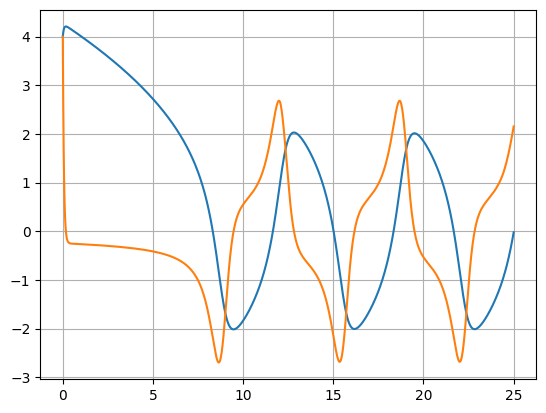

In [5]:
fig, axe = plt.subplots()
axe.plot(t, solution.y.T)
axe.grid()

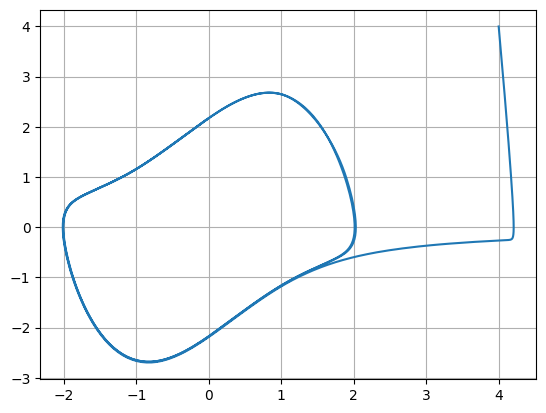

In [6]:
fig, axe = plt.subplots()
axe.plot(*solution.y)
axe.grid()

In [15]:
path = [y0]
solver = integrate.RK45(model, t.min(), y0, t.max(), max_step=0.01)
while solver.status == 'running':
    solver.step()
    y = np.array(path)
    dy = np.sum((y - solver.y) ** 2, axis=1)
    path.append(solver.y)
    if np.min(dy) < 5.5e-6:
        break

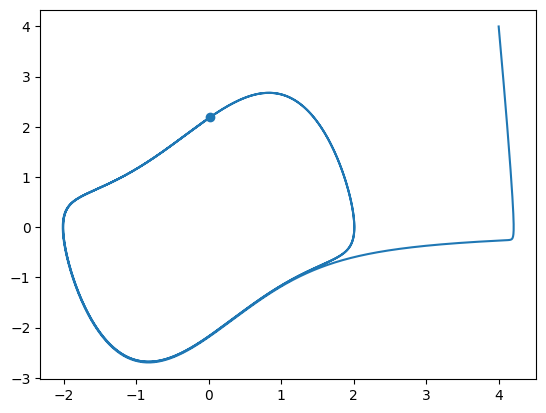

In [16]:
fig, axe = plt.subplots()
axe.plot(*y.T)
axe.scatter(*y[-1,:])